In [1]:

# Importar librerías y archivos para Entrenamiento e Inferencia
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

from params import SOAparams
from soa_main import run_simulation, plot_results

from params_predict import SOAparams_predict
from soa_main_predict import run_simulation_predict, plot_results_predict, plot_eye_diagrams_predict

Simulando propagación en SOA...
BER = 0.000e+00 | Offset Óptimo: 16


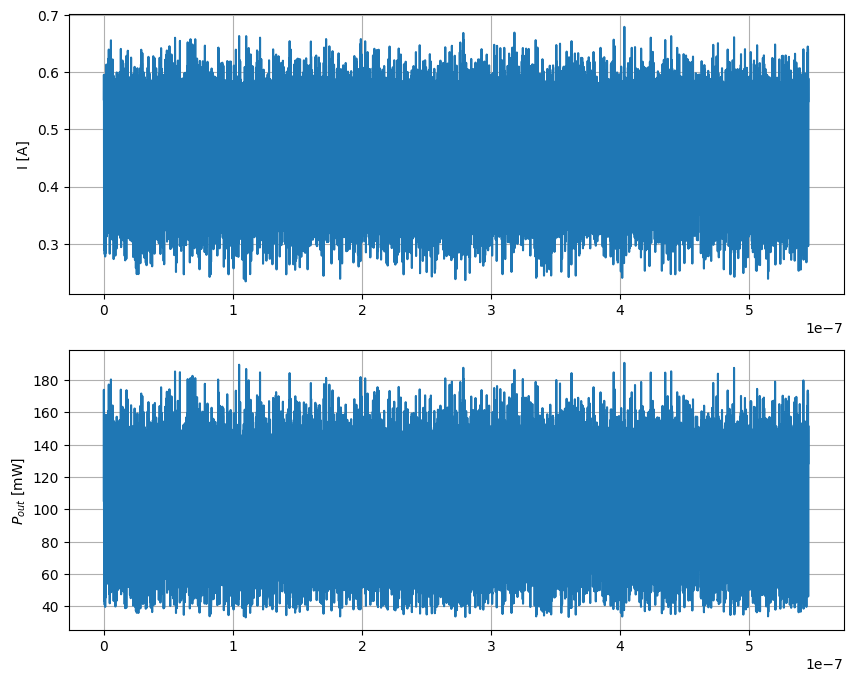

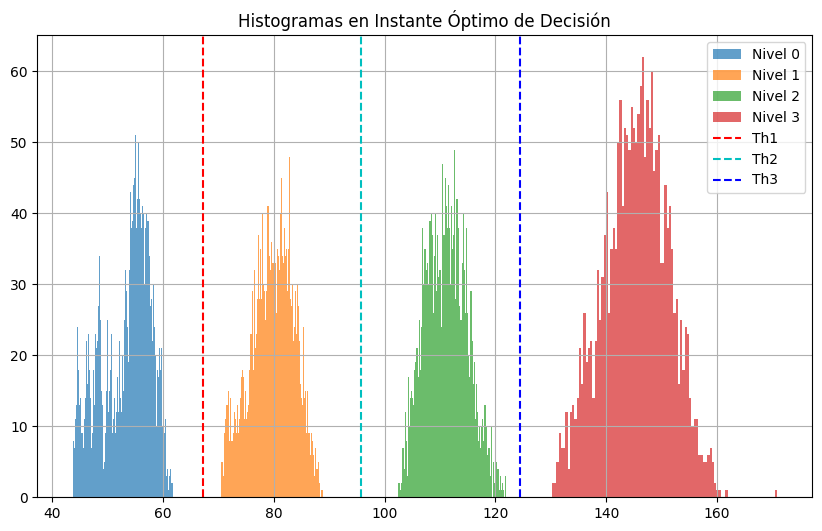

In [2]:
# ENTRENAMIENTO
# Instanciar parámetros globales
p = SOAparams()
# I_trim es la corriente ideal (PAM-4)
# P_out_trim es la potencia óptica distorsionada
I_trim, P_out_trim, P_levels, thresholds, off_best = run_simulation()
# Gráficas de resultados e histogramas
plot_results(I_trim, P_out_trim, P_levels, thresholds, p.sample_period)

In [3]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. CONFIGURACIÓN GLOBAL
WINDOW_SIZE = 32

# 2. PREPARACIÓN DE DATOS DE ENTRENAMIENTO
df_train = pd.DataFrame({
    'Time_s': np.arange(len(I_trim)) * p.sample_period,
    'Current_Input_A': I_trim,
    'Power_Output_mW': P_out_trim * 1e3 
})

def prepare_training_data(df, window_size):
    X_raw = df['Power_Output_mW'].values.reshape(-1, 1)
    y_raw = df['Current_Input_A'].values.reshape(-1, 1)
    
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_scaled = scaler_X.fit_transform(X_raw) # Escala
    y_scaled = scaler_y.fit_transform(y_raw)
    
    X_seq, y_seq = [], []
    offset = window_size // 2 
    for i in range(len(X_scaled) - window_size):
        X_seq.append(X_scaled[i : i + window_size])
        y_seq.append(y_scaled[i + offset])
        
    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

# Procesar datos
X, y, scaler_X, scaler_y = prepare_training_data(df_train, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. DEFINICIÓN DEL MODELO BiLSTM
model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)), 
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') 
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 4. ENTRENAMIENTO
print("Entrenando BiLSTM con datos base...")
history = model.fit(
    X_train, y_train,
    epochs=15, 
    batch_size=256, 
    validation_split=0.1,
    verbose=1
)

Entrenando BiLSTM con datos base...
Epoch 1/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - loss: 0.0027 - val_loss: 1.4059e-04
Epoch 2/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - loss: 1.4946e-04 - val_loss: 1.3058e-04
Epoch 3/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - loss: 1.4343e-04 - val_loss: 1.2577e-04
Epoch 4/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - loss: 1.4183e-04 - val_loss: 1.7595e-04
Epoch 5/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - loss: 1.3930e-04 - val_loss: 1.3115e-04
Epoch 6/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - loss: 1.3140e-04 - val_loss: 1.1634e-04
Epoch 7/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - loss: 1.2808e-04 - val_loss: 1.5234e-04
Epoch 8/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 1.2841e-04 - val_loss: 1.1463e-04
Epoch 9/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 1.2369e-04 - val_loss: 1.1974e-04
Epoch 10/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - loss: 1.2352e-04 - val_loss: 1.1097e-04
Epoch 1

Simulando propagación en SOA...
BER = 0.000e+00 | Offset Óptimo: 16


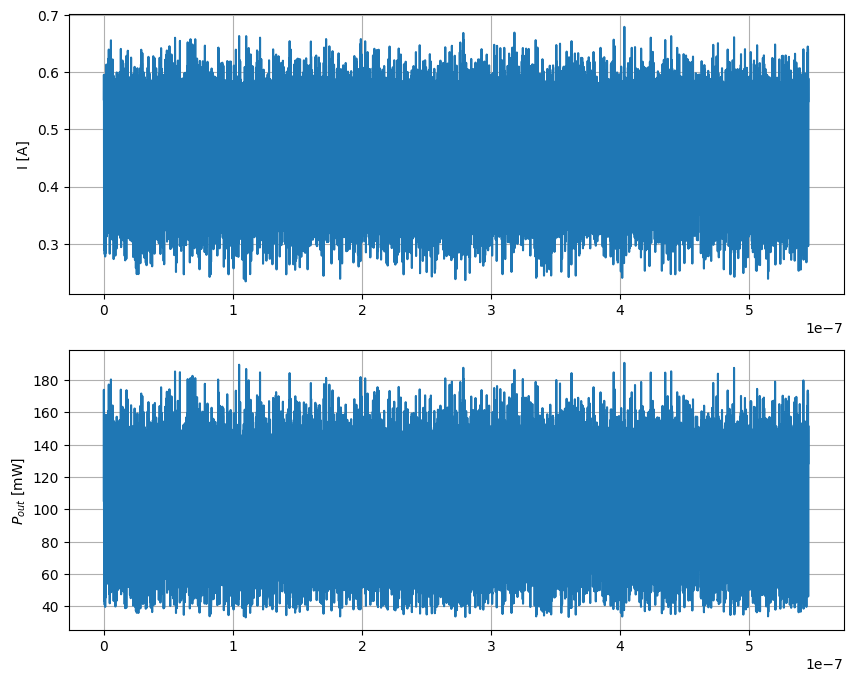

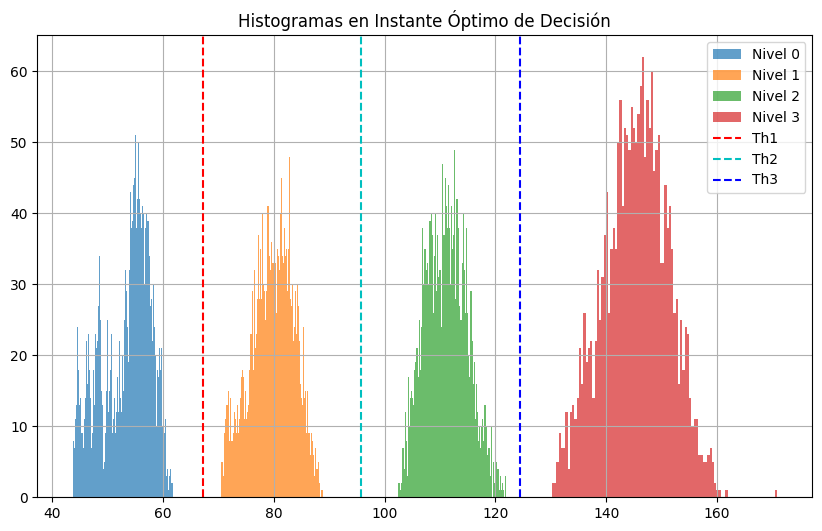

In [4]:
# INFERENCIA
# Instanciar parámetros globales
p_predict = SOAparams_predict()
# I_trim_predict es la corriente ideal (PAM-4)
# P_out_trim_predict es la potencia óptica distorsionada
I_trim_predict, P_out_trim_predict, P_levels_predict, thresholds_predict, off_best_predict = run_simulation_predict()
# Gráficas de resultados e histogramas
plot_results_predict(I_trim_predict, P_out_trim_predict, P_levels_predict, thresholds_predict, p_predict.sample_period)

Realizando inferencia sobre datos con nuevos parámetros...
8189/8189 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step


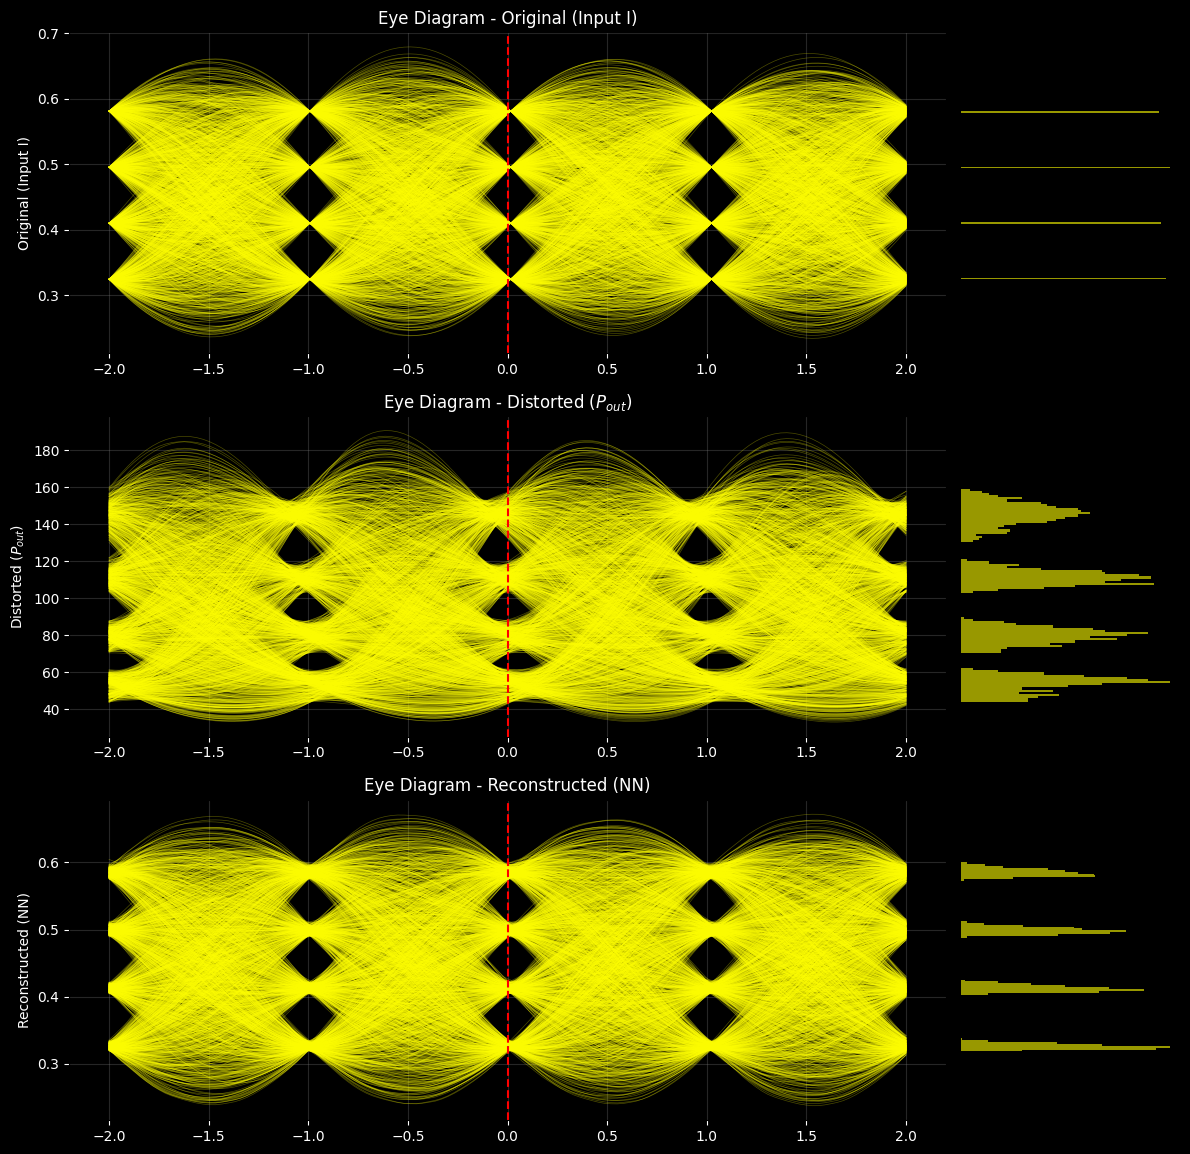

In [5]:
# INFERENCIA SOBRE NUEVA SIMULACIÓN
df_unseen = pd.DataFrame({
    'Power_Output_mW': P_out_trim_predict * 1e3  
}) 

# Preprocesamiento
X_unseen_raw = df_unseen['Power_Output_mW'].values.reshape(-1, 1)

# scaler_X viene del bloque de entrenamiento
X_unseen_scaled = scaler_X.transform(X_unseen_raw)

# Crear secuencias
X_unseen_seq = []
for i in range(len(X_unseen_scaled) - WINDOW_SIZE):
    X_unseen_seq.append(X_unseen_scaled[i : i + WINDOW_SIZE])
X_unseen_seq = np.array(X_unseen_seq)

# Predicción
print("Realizando inferencia sobre datos con nuevos parámetros...")
y_pred_unseen_scaled = model.predict(X_unseen_seq)

# Volver a unidades de Amperios usando el scaler original
y_reconstructed = scaler_y.inverse_transform(y_pred_unseen_scaled)

# Alineación para diagrama de ojos (Utilizar offset de la ventana para alinear)
start_idx_unseen = WINDOW_SIZE // 2
shift_unseen = (p_predict.samples_per_bit - (start_idx_unseen % p_predict.samples_per_bit)) % p_predict.samples_per_bit

# Recorte final
y_true_final = I_trim_predict[start_idx_unseen + shift_unseen:]
P_dist_final = P_out_trim_predict[start_idx_unseen + shift_unseen:]
y_reco_final = y_reconstructed[shift_unseen:]

# Graficar resultados
min_len = min(len(y_true_final), len(P_dist_final), len(y_reco_final))

signals_unseen = [
    (y_true_final[:min_len].flatten(), 'Original (Input I)', 1.0),
    (P_dist_final[:min_len].flatten(), 'Distorted ($P_{out}$)', 1e3),
    (y_reco_final[:min_len].flatten(), 'Reconstructed (NN)', 1.0)
]
plot_eye_diagrams_predict(signals_unseen, p_predict.samples_per_bit, off_best_predict)